# Intelligent Student Performance Assessment and Intervention System
**Student:** Nathan Bvumbwe | **Reg:** BSDS0322 | **Institution:** Mzuzu University, ICT Department

### Two-Layer Architecture
- **Layer 1 — Rule engine:** maps `exam_score` directly to Mzuni bands (always policy-correct)
- **Layer 2 — ML model:** trained on behavioural features to explain *why* and generate recommendations

Run cells top to bottom. The trained model is saved at the end so the application can load it.

## Stage 1 — Install, Import & Load Data

In [1]:
pip install shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import shap
import joblib
import os, warnings
warnings.filterwarnings('ignore')

os.makedirs('report_assets', exist_ok=True)
os.makedirs('app_model', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})
print('Libraries loaded successfully.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\user\anaconda3\envs\student_perf_env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\user\anaconda3\envs\student_perf_env\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\user\anaconda3\envs\student_perf_env\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self

AttributeError: _ARRAY_API not found

Libraries loaded successfully.


> **Upload your dataset:** Click the folder icon on the left sidebar in Colab, then upload `student_performance_dataset_bigger.csv`.

In [3]:
DATA_PATH = 'student_performance_dataset_bigger.csv'

# NEW — local version, full dataset
df_full = pd.read_csv(DATA_PATH)
df = df_full.copy().reset_index(drop=True)
print(f'Using full dataset: {len(df):,} rows')

print(f'Full dataset : {df_full.shape[0]:,} rows')
print(f'Working sample: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head()

Using full dataset: 1,000,000 rows
Full dataset : 1,000,000 rows
Working sample: 1,000,000 rows, 9 columns
Columns: ['student_id', 'age', 'gender', 'study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'exam_score', 'performance_level']
Missing values:
student_id               0
age                      0
gender                   0
study_hours_per_day      0
attendance_percentage    0
sleep_hours              0
internet_usage_hours     0
exam_score               0
performance_level        0
dtype: int64


,student_id,age,gender,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score,performance_level
0,1,24,Male,2.0,80.9,5.8,3.6,40.1,Poor
1,2,21,Female,3.0,94.2,5.0,1.5,54.2,Average
2,3,22,Male,1.3,76.2,6.5,2.3,25.4,Poor
3,4,24,Female,6.3,84.2,8.2,5.6,86.8,Excellent
4,5,20,Female,5.3,95.4,4.0,1.6,66.0,Average


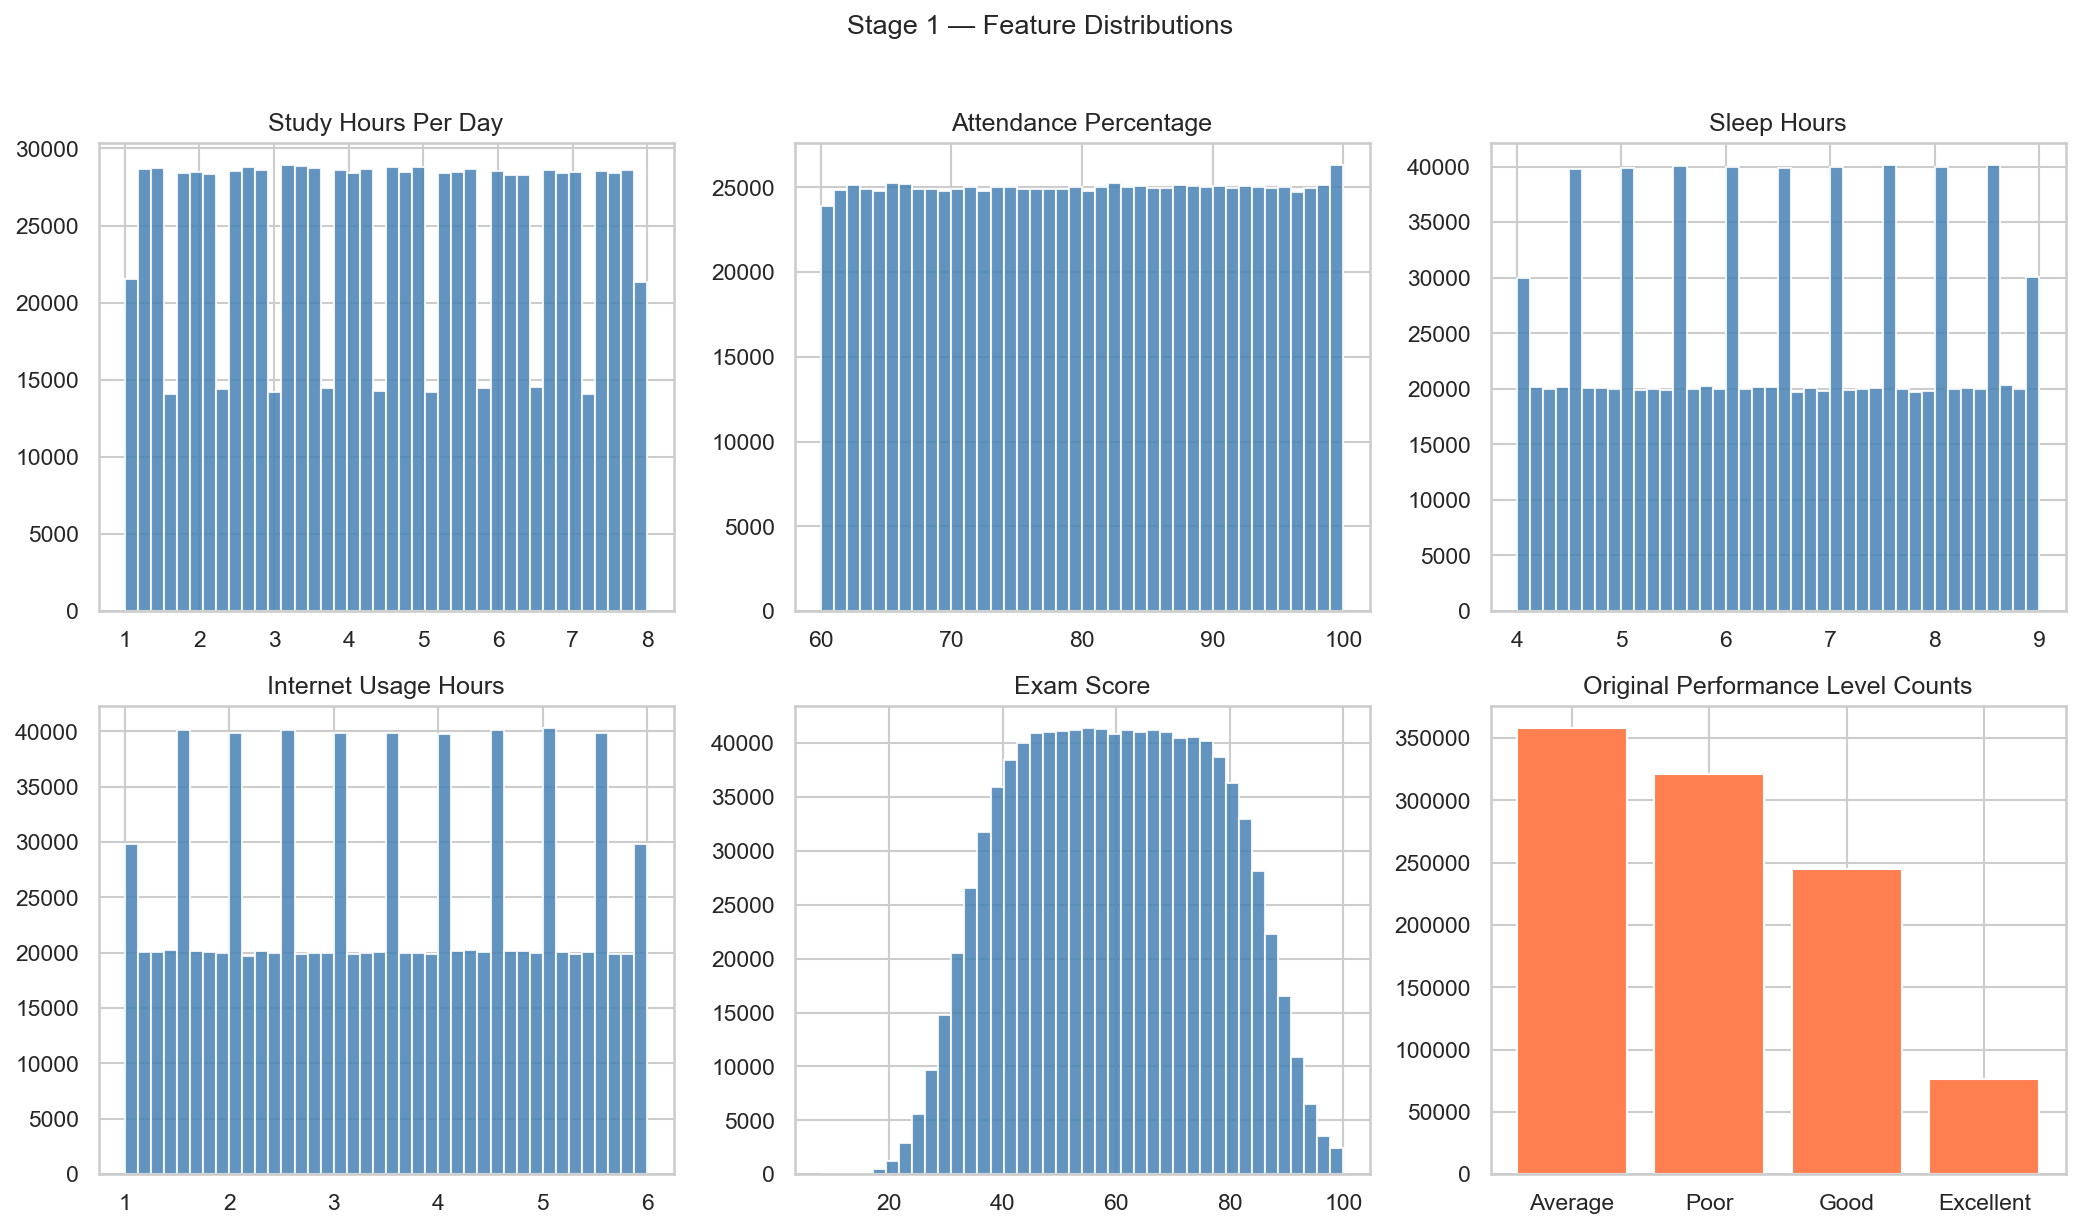

Saved: report_assets/01_distributions.png


In [4]:
num_cols = ['study_hours_per_day','attendance_percentage','sleep_hours','internet_usage_hours','exam_score']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_',' ').title())
axes[-1].bar(df['performance_level'].value_counts().index,
             df['performance_level'].value_counts().values, color='coral')
axes[-1].set_title('Original Performance Level Counts')
plt.suptitle('Stage 1 — Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('report_assets/01_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/01_distributions.png')

## Stage 2 — Preprocess & Feature Engineering

=== Layer 1: Mzuni Band Distribution ===
  Repeat         :  64,251  (6.4%)
  Supplementary  : 151,658  (15.2%)
  Good           : 357,505  (35.8%)
  Excellent      : 426,586  (42.7%)

Scaler saved to app_model/scaler.pkl


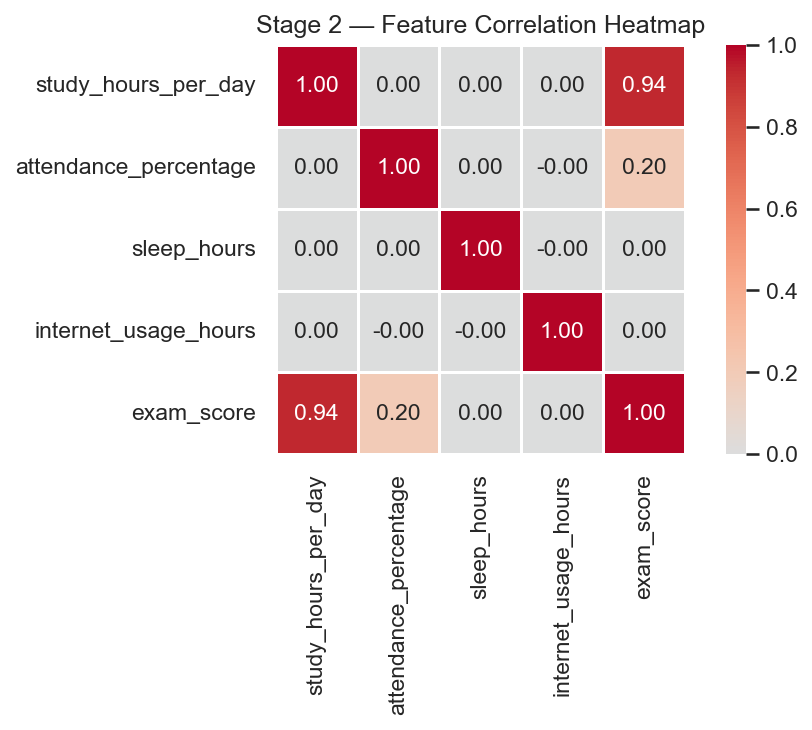

Saved: report_assets/02_correlation_heatmap.png


In [5]:
# ── LAYER 1: Rule-based Mzuni band assignment ──────────────────────────
# Thresholds are taken directly from the project proposal.
# This mapping is deterministic and always policy-correct.
BAND_THRESHOLDS = {
    'Repeat':        (0,  34),
    'Supplementary': (35, 44),
    'Good':          (45, 64),
    'Excellent':     (65, 100),
}
BAND_ORDER = ['Repeat', 'Supplementary', 'Good', 'Excellent']
BAND_TO_INT = {b: i for i, b in enumerate(BAND_ORDER)}

def assign_mzuni_band(score):
    """Layer 1: deterministic rule engine — always matches Mzuni policy."""
    if score <= 34:  return 'Repeat'
    elif score <= 44: return 'Supplementary'
    elif score <= 64: return 'Good'
    else:             return 'Excellent'

df['mzuni_band'] = df['exam_score'].apply(assign_mzuni_band)
df['mzuni_band_int'] = df['mzuni_band'].map(BAND_TO_INT)

print('=== Layer 1: Mzuni Band Distribution ===')
band_counts = df['mzuni_band'].value_counts().reindex(BAND_ORDER)
for band, count in band_counts.items():
    pct = count / len(df) * 100
    print(f'  {band:<15}: {count:>7,}  ({pct:.1f}%)')

# ── Feature engineering ────────────────────────────────────────────────
df['gender_enc'] = (df['gender'] == 'Male').astype(int)

# Behavioural features only (exam_score excluded from Layer 2 features
# so the model learns the behavioural drivers, not just the score itself)
BEHAV_FEATURES = ['study_hours_per_day', 'attendance_percentage',
                  'sleep_hours', 'internet_usage_hours']

# Full feature set (includes exam_score — used for the combined model)
ALL_FEATURES = BEHAV_FEATURES + ['exam_score']

# ── Scaling ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(df[ALL_FEATURES])

# Save scaler immediately — the app will need it
joblib.dump(scaler, 'app_model/scaler.pkl')
joblib.dump(ALL_FEATURES, 'app_model/feature_names.pkl')
print('\nScaler saved to app_model/scaler.pkl')

# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[ALL_FEATURES].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Stage 2 — Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('report_assets/02_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/02_correlation_heatmap.png')

## Stage 3 — Layer 2: Train the ML Classifier

> The target variable is now the **rule-based Mzuni band** (not K-Means clusters).
> This ensures band assignment is always policy-correct while the ML model
> learns which behavioural patterns predict each band.

In [6]:
X = df[ALL_FEATURES]
y = df['mzuni_band_int']   # 0=Repeat, 1=Supplementary, 2=Good, 3=Excellent

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} samples')
print(f'Test : {len(X_test):,} samples')
print(f'\nClass distribution in train:')
for i, b in enumerate(BAND_ORDER):
    n = (y_train == i).sum()
    print(f'  {b:<15}: {n:,}')

Train: 800,000 samples
Test : 200,000 samples

Class distribution in train:
  Repeat         : 51,401
  Supplementary  : 121,326
  Good           : 286,004
  Excellent      : 341,269


In [7]:
# Train Random Forest — this IS the Layer 2 model (not a surrogate)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # handles any class imbalance
)
rf.fit(X_train, y_train)
print('Model trained.')

# Cross-validation (5-fold) — gives honest estimate of generalisation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f'\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'CV scores per fold: {[round(s,4) for s in cv_scores]}')

Model trained.

5-Fold CV Accuracy: 1.0000 ± 0.0000
CV scores per fold: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]


=== Layer 2 Classification Report ===
               precision    recall  f1-score   support

       Repeat       1.00      1.00      1.00     12850
Supplementary       1.00      1.00      1.00     30332
         Good       1.00      1.00      1.00     71501
    Excellent       1.00      1.00      1.00     85317

     accuracy                           1.00    200000
    macro avg       1.00      1.00      1.00    200000
 weighted avg       1.00      1.00      1.00    200000



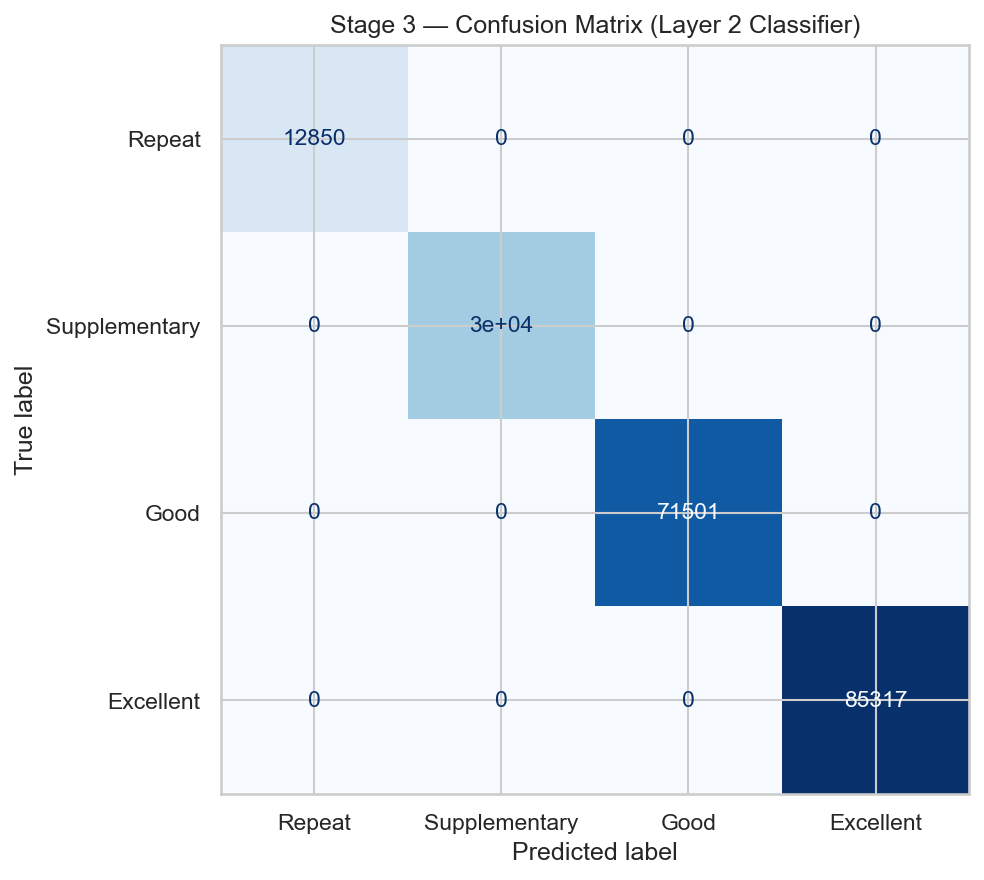

Saved: report_assets/03_confusion_matrix.png


In [8]:
y_pred = rf.predict(X_test)

print('=== Layer 2 Classification Report ===')
print(classification_report(y_test, y_pred, target_names=BAND_ORDER))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=BAND_ORDER)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Stage 3 — Confusion Matrix (Layer 2 Classifier)')
plt.tight_layout()
plt.savefig('report_assets/03_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/03_confusion_matrix.png')

In [9]:
# ── Save the trained model ─────────────────────────────────────────────
# The app will load these files instead of retraining every time.
joblib.dump(rf,          'app_model/rf_model.pkl')
joblib.dump(BAND_ORDER,  'app_model/band_order.pkl')
joblib.dump(BAND_TO_INT, 'app_model/band_to_int.pkl')

print('Model artefacts saved:')
for f in os.listdir('app_model'):
    size = os.path.getsize(f'app_model/{f}') / 1024
    print(f'  app_model/{f}  ({size:.1f} KB)')

Model artefacts saved:
  app_model/band_order.pkl  (0.1 KB)
  app_model/band_to_int.pkl  (0.1 KB)
  app_model/behav_feature_names.pkl  (0.1 KB)
  app_model/feature_names.pkl  (0.1 KB)
  app_model/rf_behav_model.pkl  (107024.4 KB)
  app_model/rf_model.pkl  (5764.8 KB)
  app_model/scaler.pkl  (1.0 KB)


In [10]:
# ── Behavioural-only model (no exam score) ──────────────────────────────
# This answers: can we identify at-risk students from behaviour alone,
# BEFORE they sit the exam? This is the early warning system.

X_behav_train = X_train[BEHAV_FEATURES]
X_behav_test  = X_test[BEHAV_FEATURES]

rf_behav = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_behav.fit(X_behav_train, y_train)

y_pred_behav = rf_behav.predict(X_behav_test)
print('=== Behavioural-Only Model (early warning — no exam score) ===')
print(classification_report(y_test, y_pred_behav, target_names=BAND_ORDER))

# Save this model too — the app will use it for early warnings
joblib.dump(rf_behav, 'app_model/rf_behav_model.pkl')
joblib.dump(BEHAV_FEATURES, 'app_model/behav_feature_names.pkl')
print('Saved: app_model/rf_behav_model.pkl')

=== Behavioural-Only Model (early warning — no exam score) ===
               precision    recall  f1-score   support

       Repeat       0.55      0.75      0.64     12850
Supplementary       0.57      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.90      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000

Saved: app_model/rf_behav_model.pkl


In [25]:
# Reduce behavioural model size — fewer trees, still good accuracy
rf_behav_small = RandomForestClassifier(
    n_estimators=50,       # down from 200
    max_depth=10,          # down from 12
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_behav_small.fit(X_behav_train, y_train)
y_pred_small = rf_behav_small.predict(X_behav_test)
print(classification_report(y_test, y_pred_small, target_names=BAND_ORDER))
joblib.dump(rf_behav_small, f'{MODEL_DIR}rf_behav_model.pkl')

import os
kb = os.path.getsize(f'{MODEL_DIR}rf_behav_model.pkl') / 1024
print(f'New behavioural model size: {kb:.0f} KB')

               precision    recall  f1-score   support

       Repeat       0.55      0.76      0.64     12850
Supplementary       0.56      0.64      0.60     30332
         Good       0.82      0.74      0.78     71501
    Excellent       0.93      0.90      0.92     85317

     accuracy                           0.80    200000
    macro avg       0.72      0.76      0.73    200000
 weighted avg       0.81      0.80      0.80    200000



NameError: name 'MODEL_DIR' is not defined

In [26]:
joblib.dump(rf_behav_small, f'{MODEL_DIR}rf_behav_model.pkl')

NameError: name 'MODEL_DIR' is not defined

## Stage 4 — Visualise & Validate Bands

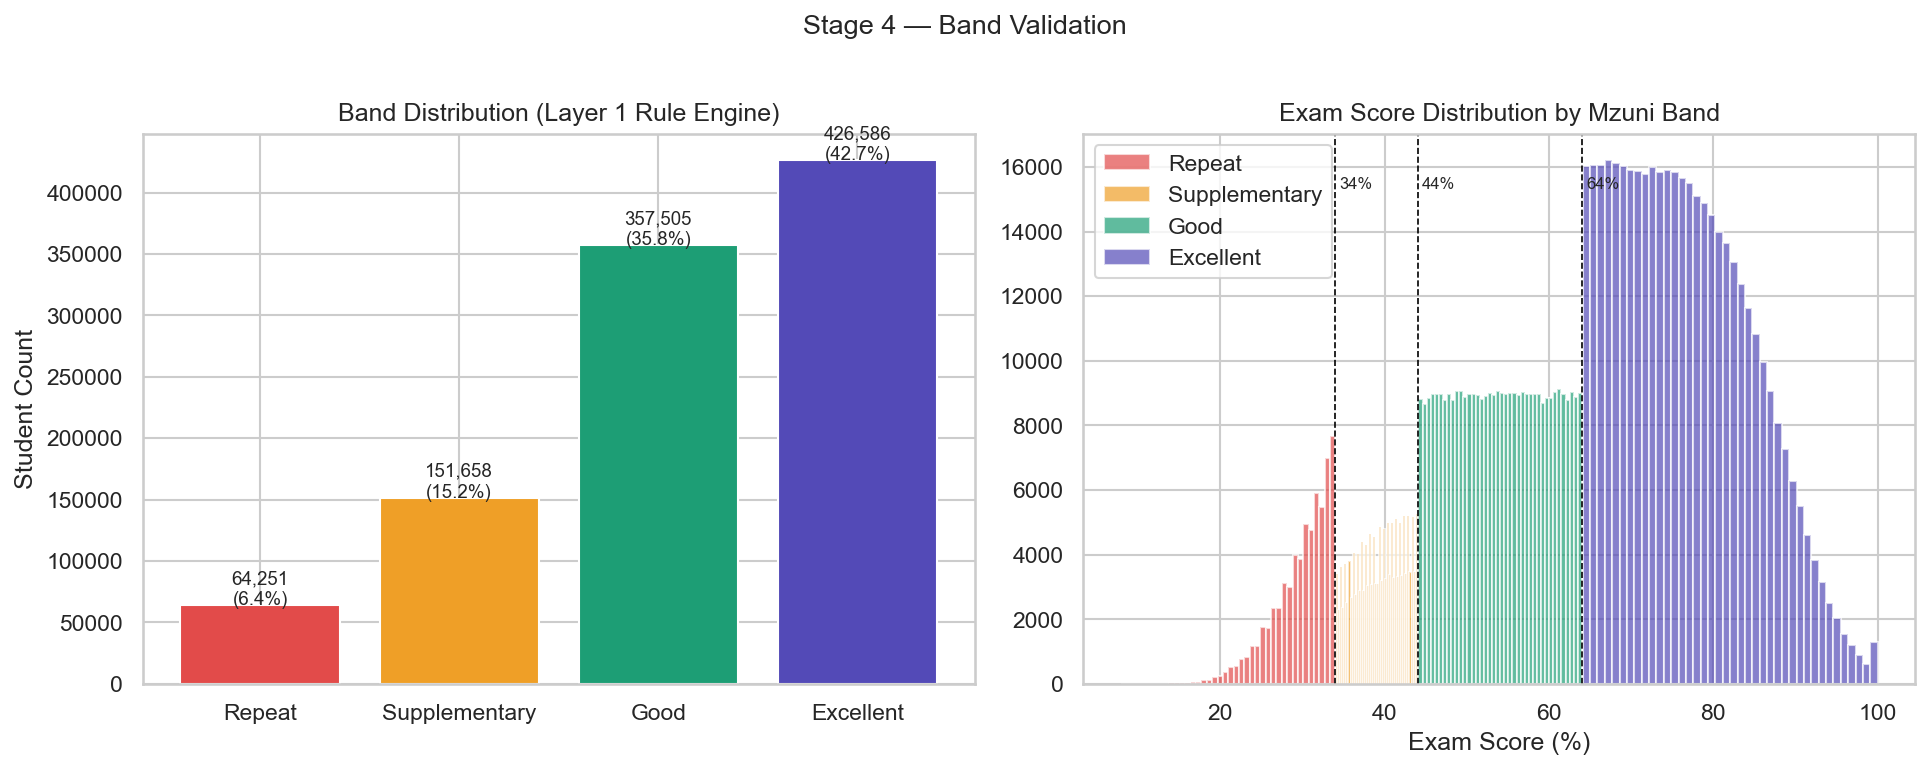

Saved: report_assets/04_band_distribution.png


In [11]:
# Band distribution bar chart
palette = {'Repeat':'#E24B4A','Supplementary':'#EF9F27','Good':'#1D9E75','Excellent':'#534AB7'}
band_counts = df['mzuni_band'].value_counts().reindex(BAND_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: counts
axes[0].bar(BAND_ORDER, band_counts.values,
            color=[palette[b] for b in BAND_ORDER], edgecolor='white')
axes[0].set_title('Band Distribution (Layer 1 Rule Engine)')
axes[0].set_ylabel('Student Count')
for i, v in enumerate(band_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)

# Right: exam score distribution coloured by band
for band in BAND_ORDER:
    subset = df[df['mzuni_band'] == band]['exam_score']
    axes[1].hist(subset, bins=40, alpha=0.7, label=band,
                 color=palette[band], edgecolor='white')
# Draw threshold lines
for thresh, label in [(34,'34%'),(44,'44%'),(64,'64%')]:
    axes[1].axvline(thresh, color='black', linestyle='--', linewidth=0.8)
    axes[1].text(thresh+0.5, axes[1].get_ylim()[1]*0.9, label, fontsize=8)
axes[1].set_title('Exam Score Distribution by Mzuni Band')
axes[1].set_xlabel('Exam Score (%)')
axes[1].legend()

plt.suptitle('Stage 4 — Band Validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('report_assets/04_band_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/04_band_distribution.png')

=== Band Feature Profiles ===


,study_hours_per_day,attendance_percentage,sleep_hours,internet_usage_hours,exam_score,count,% of total
mzuni_band,,,,,,,
Repeat,1.53,72.93,6.5,3.5,29.76,64251,6.4
Supplementary,2.11,78.37,6.5,3.5,39.40,151658,15.2
Good,3.76,79.96,6.5,3.5,54.06,357505,35.8
Excellent,6.41,81.69,6.5,3.5,76.80,426586,42.7


Saved: report_assets/04_band_profiles.csv


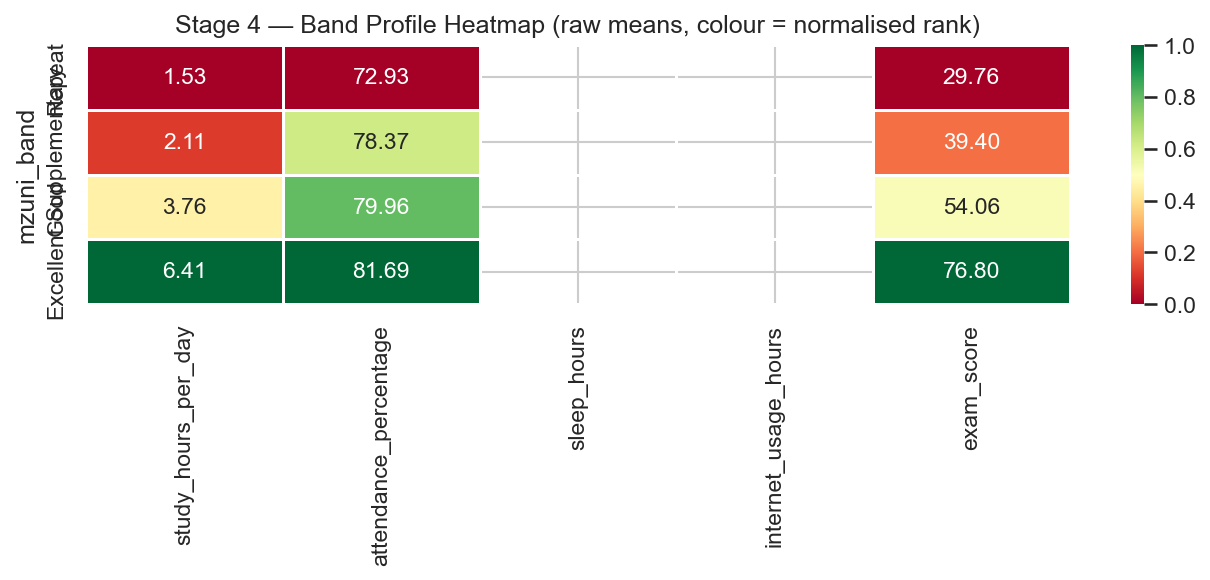

Saved: report_assets/04b_band_heatmap.png


In [12]:
# Feature profile per band — the story behind each group
profile = df.groupby('mzuni_band')[ALL_FEATURES].mean().round(2).reindex(BAND_ORDER)
profile['count'] = df['mzuni_band'].value_counts().reindex(BAND_ORDER)
profile['% of total'] = (profile['count'] / len(df) * 100).round(1)
print('=== Band Feature Profiles ===')
display(profile)
profile.to_csv('report_assets/04_band_profiles.csv')
print('Saved: report_assets/04_band_profiles.csv')

# Heatmap
profile_norm = (profile[ALL_FEATURES] - profile[ALL_FEATURES].min()) / \
               (profile[ALL_FEATURES].max() - profile[ALL_FEATURES].min())
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_norm, annot=profile[ALL_FEATURES],
            fmt='.2f', cmap='RdYlGn', linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Stage 4 — Band Profile Heatmap (raw means, colour = normalised rank)')
plt.tight_layout()
plt.savefig('report_assets/04b_band_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/04b_band_heatmap.png')

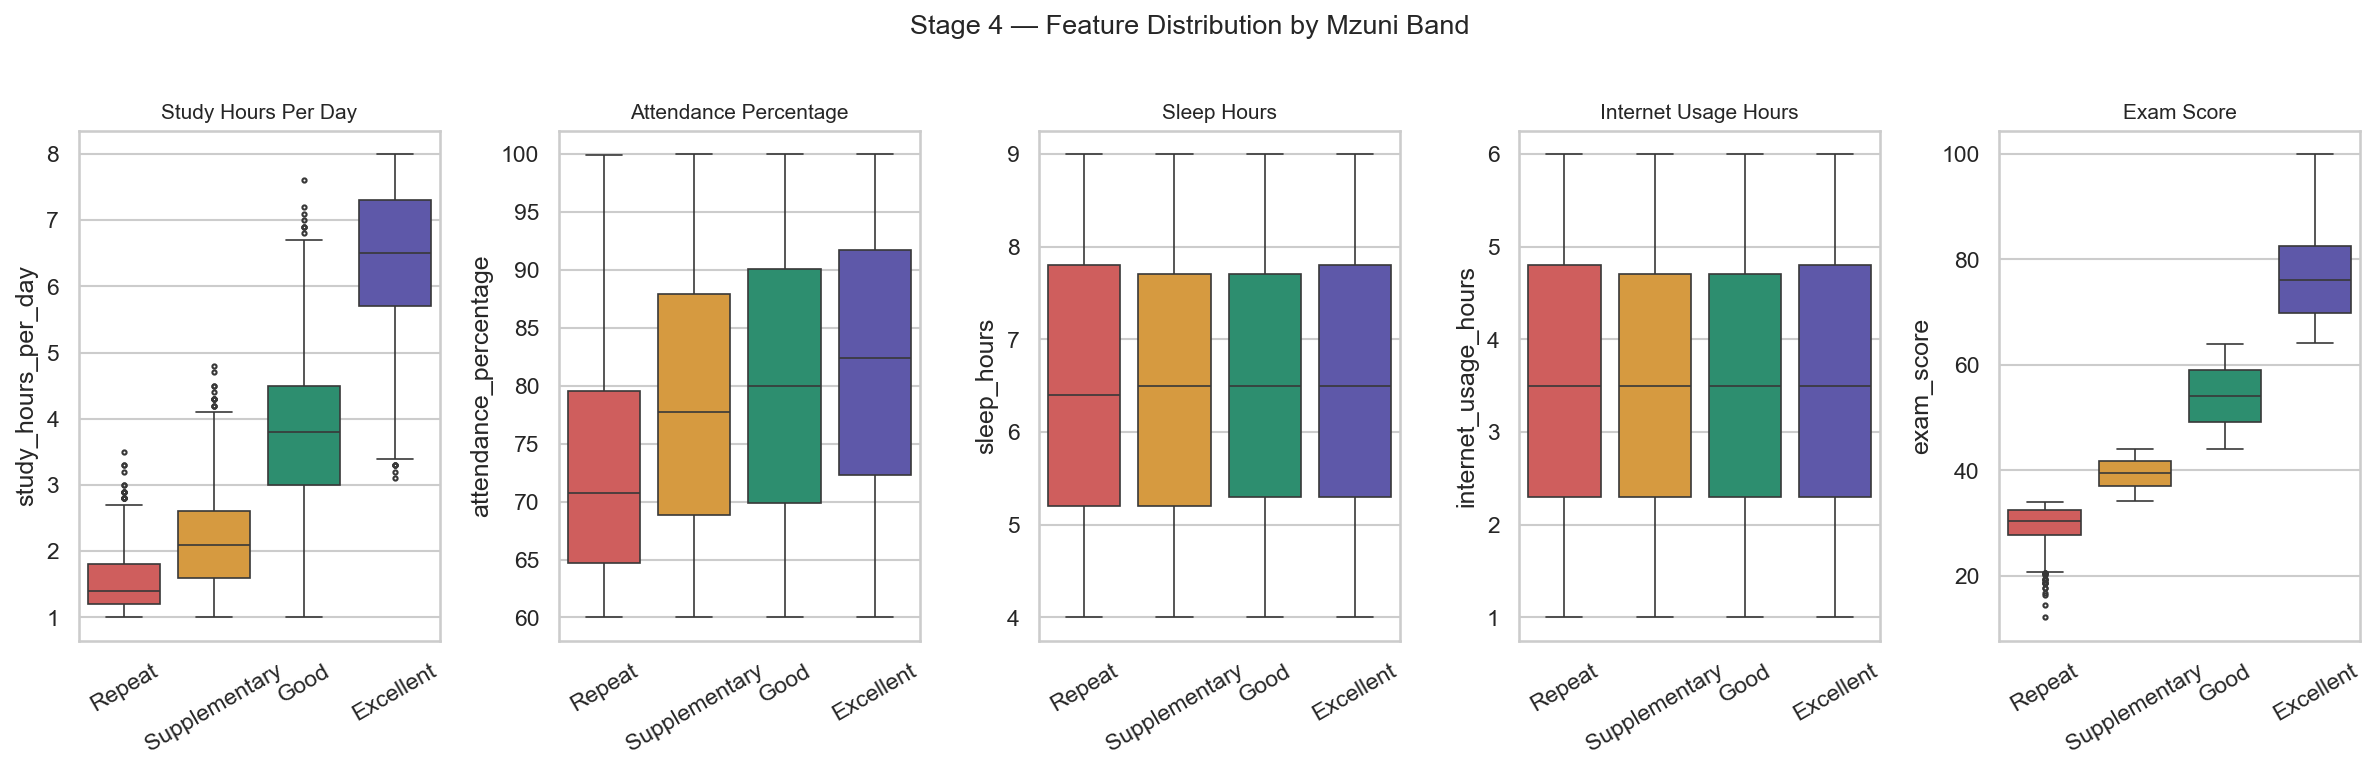

Saved: report_assets/04c_boxplots.png


In [13]:
fig, axes = plt.subplots(1, len(ALL_FEATURES), figsize=(16, 5))
for ax, col in zip(axes, ALL_FEATURES):
    sns.boxplot(data=df.sample(20_000, random_state=2),
                x='mzuni_band', y=col, order=BAND_ORDER,
                palette=palette, ax=ax, linewidth=0.8, fliersize=2)
    ax.set_title(col.replace('_',' ').title(), fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Stage 4 — Feature Distribution by Mzuni Band', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('report_assets/04c_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/04c_boxplots.png')

## Stage 5 — SHAP Explainability

> SHAP now explains the **Layer 2 Random Forest** directly — not a surrogate.
> The model IS the explainable component.

In [14]:
# Use a subsample of the test set for speed
shap_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)

sv = np.array(shap_values)
print(f'SHAP values shape: {sv.shape}')

# Normalise to (n_samples, n_features, n_classes)
if sv.ndim == 3 and sv.shape[0] == shap_sample.shape[0]:
    sv_3d = sv
elif sv.ndim == 3 and sv.shape[0] == 4:
    sv_3d = sv.transpose(1, 2, 0)
else:
    raise ValueError(f'Unexpected SHAP shape: {sv.shape}')

print('Shape normalised to (n_samples, n_features, n_classes):', sv_3d.shape)

SHAP values shape: (2000, 5, 4)
Shape normalised to (n_samples, n_features, n_classes): (2000, 5, 4)


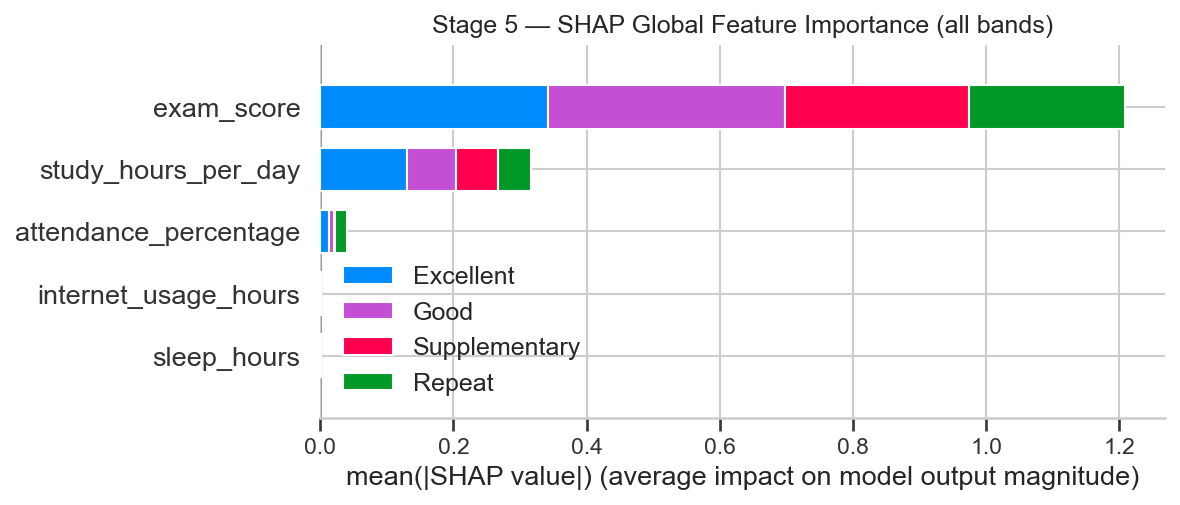

Saved: report_assets/05a_shap_global.png


In [15]:
# Global feature importance bar chart
shap.summary_plot(sv_3d, shap_sample,
                  class_names=BAND_ORDER, plot_type='bar', show=False)
plt.title('Stage 5 — SHAP Global Feature Importance (all bands)')
plt.tight_layout()
plt.savefig('report_assets/05a_shap_global.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/05a_shap_global.png')

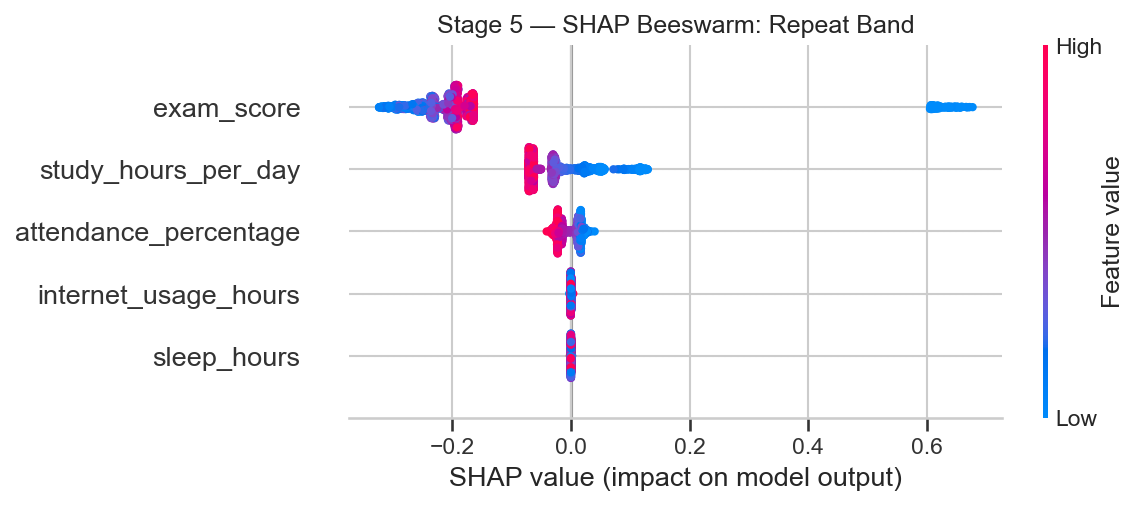

Saved: report_assets/05b_shap_repeat.png


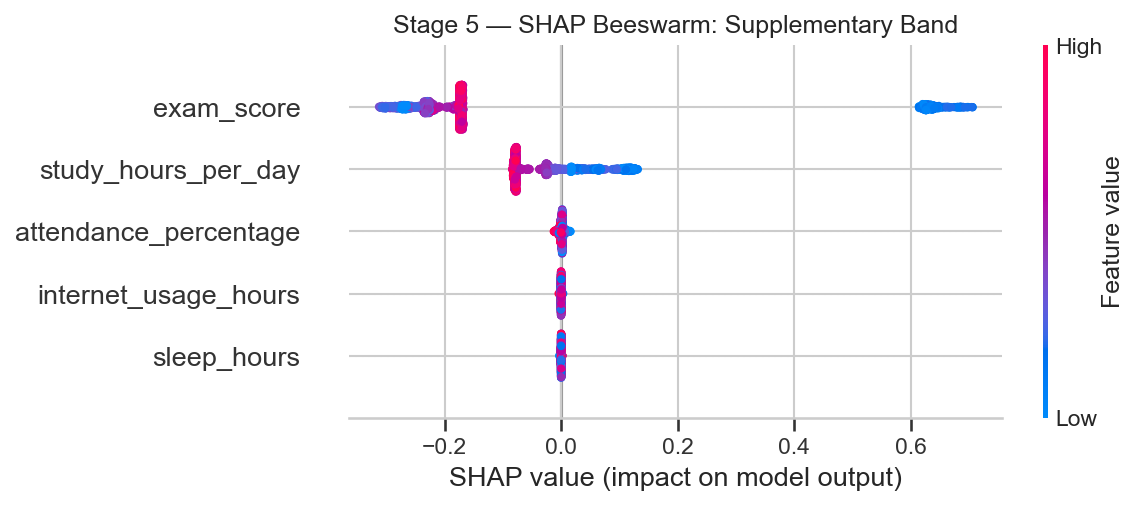

Saved: report_assets/05c_shap_supplementary.png


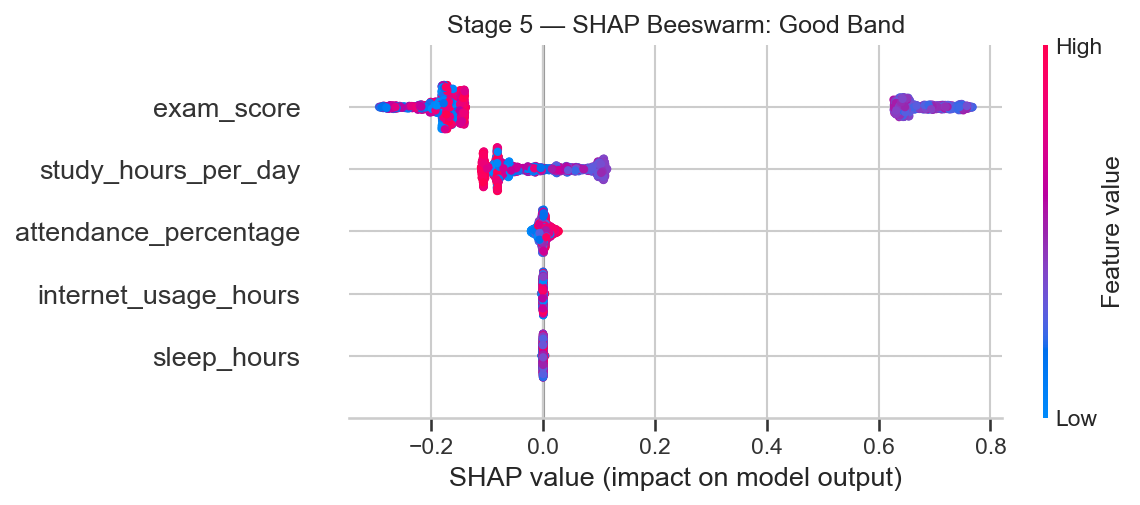

Saved: report_assets/05d_shap_good.png


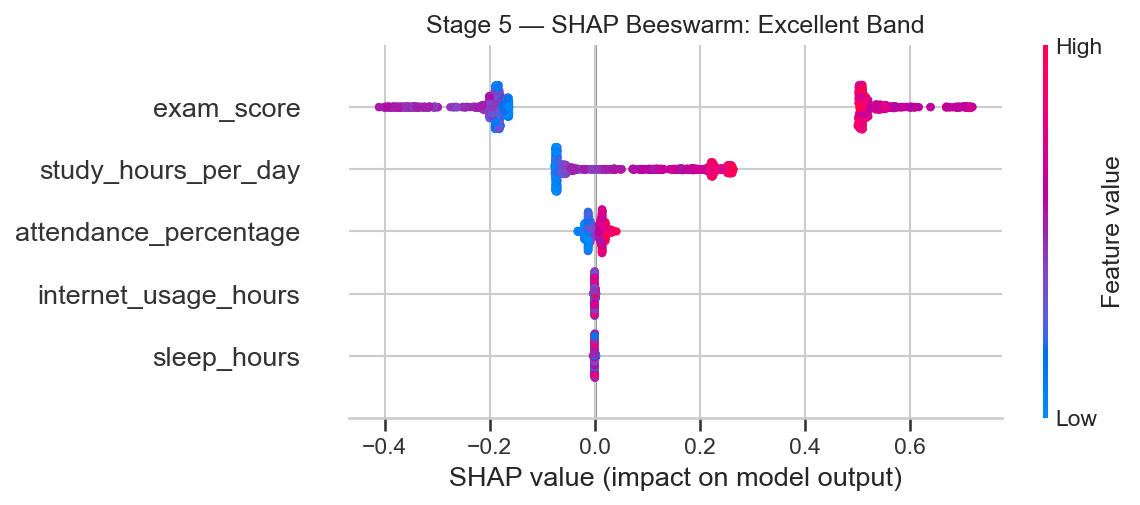

Saved: report_assets/05e_shap_excellent.png


In [16]:
# Beeswarm per band — most critical bands first
band_plots = [
    (0, 'Repeat',        '05b_shap_repeat.png'),
    (1, 'Supplementary', '05c_shap_supplementary.png'),
    (2, 'Good',          '05d_shap_good.png'),
    (3, 'Excellent',     '05e_shap_excellent.png'),
]
for class_idx, band_name, fname in band_plots:
    sv_class = sv_3d[:, :, class_idx]
    shap.summary_plot(sv_class, shap_sample, show=False)
    plt.title(f'Stage 5 — SHAP Beeswarm: {band_name} Band')
    plt.tight_layout()
    plt.savefig(f'report_assets/{fname}', bbox_inches='tight')
    plt.show()
    print(f'Saved: report_assets/{fname}')

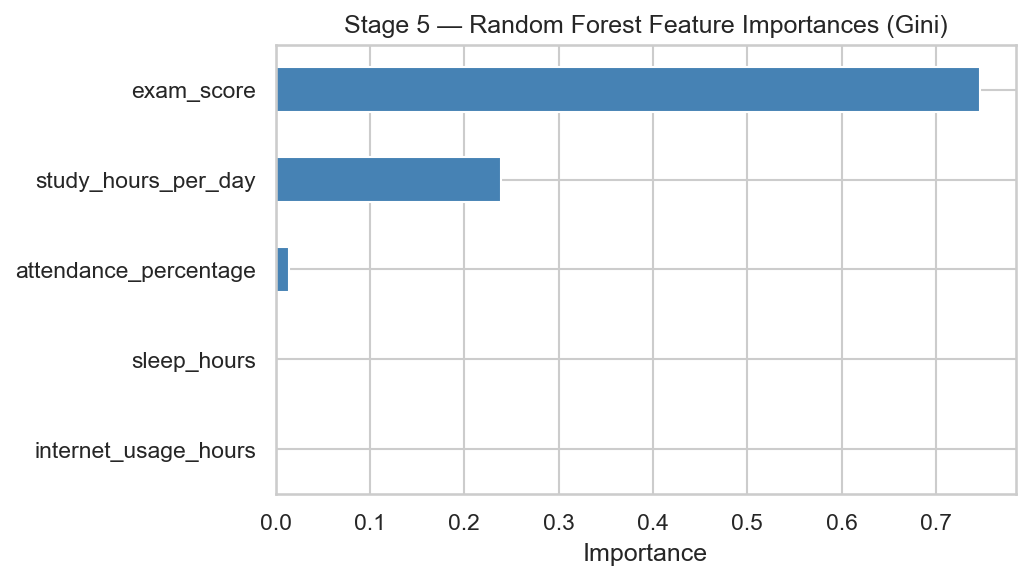

Saved: report_assets/05f_rf_importances.png

Feature importances:
exam_score               0.746985
study_hours_per_day      0.238429
attendance_percentage    0.014437
sleep_hours              0.000075
internet_usage_hours     0.000074


In [17]:
# Feature importance from the RF itself (as a cross-check against SHAP)
importances = pd.Series(rf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Stage 5 — Random Forest Feature Importances (Gini)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('report_assets/05f_rf_importances.png', bbox_inches='tight')
plt.show()
print('Saved: report_assets/05f_rf_importances.png')
print('\nFeature importances:')
print(importances.sort_values(ascending=False).to_string())

## Stage 6 — Prediction Test (simulate the application)

> This is the most important test before building the app.
> We simulate what happens when a new student's data is passed in:
> Layer 1 assigns their band from the score rule, Layer 2 explains why
> and generates recommendations.

In [18]:
# ── Load saved artefacts (simulating what the app will do) ─────────────
loaded_rf      = joblib.load('app_model/rf_model.pkl')
loaded_scaler  = joblib.load('app_model/scaler.pkl')
loaded_bands   = joblib.load('app_model/band_order.pkl')
loaded_features= joblib.load('app_model/feature_names.pkl')
print('Model artefacts loaded successfully.')
print(f'Features expected: {loaded_features}')

# ── Recommendation engine ───────────────────────────────────────────────
RECOMMENDATIONS = {
    'Repeat': {
        'student': [
            'Seek academic counselling immediately — do not wait until exams.',
            'Increase study hours to at least 4 hours per day.',
            'Attend every class — missing even one session compounds the risk.',
            'Reduce recreational internet usage during the week.',
            'Form a study group with Good or Excellent band peers.',
        ],
        'lecturer': [
            'Flag for urgent one-on-one academic review.',
            'Escalate to the academic advisor or HOD immediately.',
            'Provide additional practice questions targeted at foundational concepts.',
            'Consider a mid-semester progress check-in.',
        ]
    },
    'Supplementary': {
        'student': [
            'You are close to the pass boundary — focused effort now can shift your outcome.',
            'Target the specific CA components where marks were lost.',
            'Attend all remaining classes and tutorials without exception.',
            'Reduce internet usage on study days.',
            'Use office hours to get feedback on weak areas.',
        ],
        'lecturer': [
            'Offer supplementary practice materials and past questions.',
            'Schedule office hours check-in for this student.',
            'Monitor attendance closely over the next two weeks.',
        ]
    },
    'Good': {
        'student': [
            'You are on track — maintain your current study routine.',
            'Push for consistency: aim to increase study hours by 30 minutes per day.',
            'Attempt past exam papers under timed conditions to build exam readiness.',
            'Set a stretch target of the Excellent band for the final exam.',
        ],
        'lecturer': [
            'Encourage with extension tasks or challenge questions.',
            'Suggest peer tutoring opportunities to reinforce knowledge.',
        ]
    },
    'Excellent': {
        'student': [
            'Outstanding performance — maintain your current habits.',
            'Consider mentoring peers in lower bands as a way to deepen your own understanding.',
            'Explore supplementary reading to prepare for advanced coursework.',
        ],
        'lecturer': [
            'Recognise and celebrate this performance publicly where appropriate.',
            'Assign a peer mentorship role to extend impact.',
        ]
    }
}

def get_top_shap_drivers(student_features_df, n=3):
    """Return the top N features driving the predicted band for this student."""
    exp = shap.TreeExplainer(loaded_rf)
    sv  = np.array(exp.shap_values(student_features_df))
    # Normalise shape
    if sv.ndim == 3 and sv.shape[0] == student_features_df.shape[0]:
        sv_3d = sv
    else:
        sv_3d = sv.transpose(1, 2, 0)
    pred_class = loaded_rf.predict(student_features_df)[0]
    sv_for_class = sv_3d[0, :, pred_class]   # shape (n_features,)
    drivers = pd.Series(np.abs(sv_for_class), index=loaded_features)\
                .sort_values(ascending=False).head(n)
    return drivers

def predict_student(student_data: dict) -> dict:
    """
    Two-layer prediction for a single student.

    Parameters
    ----------
    student_data : dict with keys matching ALL_FEATURES
        e.g. {'study_hours_per_day': 2.0, 'attendance_percentage': 55.0,
               'sleep_hours': 6.0, 'internet_usage_hours': 4.0, 'exam_score': 38.0}

    Returns
    -------
    dict with band, confidence, top drivers, and recommendations
    """
    # ── Layer 1: deterministic rule ──
    band = assign_mzuni_band(student_data['exam_score'])

    # ── Layer 2: ML model ──
    input_df = pd.DataFrame([student_data])[loaded_features]
    proba    = loaded_rf.predict_proba(input_df)[0]
    confidence = proba[BAND_TO_INT[band]] * 100

    # Top SHAP drivers
    drivers = get_top_shap_drivers(input_df, n=3)

    return {
        'band':            band,
        'confidence':      round(confidence, 1),
        'probabilities':   {b: round(proba[i]*100, 1) for i, b in enumerate(BAND_ORDER)},
        'top_drivers':     drivers.index.tolist(),
        'student_actions': RECOMMENDATIONS[band]['student'],
        'lecturer_actions':RECOMMENDATIONS[band]['lecturer'],
    }

print('Prediction function ready.')

Model artefacts loaded successfully.
Features expected: ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'exam_score']
Prediction function ready.


In [19]:
# ── Test with four synthetic students, one per band ─────────────────────
test_students = [
    {'name': 'Alice (expected: Repeat)',
     'data': {'study_hours_per_day': 1.5, 'attendance_percentage': 45.0,
               'sleep_hours': 5.0, 'internet_usage_hours': 6.0, 'exam_score': 22.0}},

    {'name': 'Bob (expected: Supplementary)',
     'data': {'study_hours_per_day': 2.5, 'attendance_percentage': 60.0,
               'sleep_hours': 6.5, 'internet_usage_hours': 4.0, 'exam_score': 40.0}},

    {'name': 'Carol (expected: Good)',
     'data': {'study_hours_per_day': 4.0, 'attendance_percentage': 78.0,
               'sleep_hours': 7.0, 'internet_usage_hours': 2.5, 'exam_score': 57.0}},

    {'name': 'David (expected: Excellent)',
     'data': {'study_hours_per_day': 6.5, 'attendance_percentage': 95.0,
               'sleep_hours': 8.0, 'internet_usage_hours': 1.0, 'exam_score': 82.0}},
]

for student in test_students:
    result = predict_student(student['data'])
    print('='*60)
    print(f"Student : {student['name']}")
    print(f"Input   : exam={student['data']['exam_score']}%, "
          f"study={student['data']['study_hours_per_day']}h, "
          f"attendance={student['data']['attendance_percentage']}%")
    print(f"Band    : {result['band']} (Layer 1 rule — always correct)")
    print(f"ML Confidence : {result['confidence']}%")
    print(f"All probabilities: {result['probabilities']}")
    print(f"Top behavioural drivers: {result['top_drivers']}")
    print(f"\nStudent actions:")
    for a in result['student_actions'][:2]: print(f'  • {a}')
    print(f"Lecturer actions:")
    for a in result['lecturer_actions'][:2]: print(f'  • {a}')
print('='*60)

Student : Alice (expected: Repeat)
Input   : exam=22.0%, study=1.5h, attendance=45.0%
Band    : Repeat (Layer 1 rule — always correct)
ML Confidence : 99.8%
All probabilities: {'Repeat': np.float64(99.8), 'Supplementary': np.float64(0.2), 'Good': np.float64(0.0), 'Excellent': np.float64(0.0)}
Top behavioural drivers: ['exam_score', 'study_hours_per_day', 'attendance_percentage']

Student actions:
  • Seek academic counselling immediately — do not wait until exams.
  • Increase study hours to at least 4 hours per day.
Lecturer actions:
  • Flag for urgent one-on-one academic review.
  • Escalate to the academic advisor or HOD immediately.
Student : Bob (expected: Supplementary)
Input   : exam=40.0%, study=2.5h, attendance=60.0%
Band    : Supplementary (Layer 1 rule — always correct)
ML Confidence : 99.7%
All probabilities: {'Repeat': np.float64(0.0), 'Supplementary': np.float64(99.7), 'Good': np.float64(0.3), 'Excellent': np.float64(0.0)}
Top behavioural drivers: ['exam_score', 'study_h

In [20]:
# ── Batch test on the held-out test set ─────────────────────────────────
# Run 500 random test students through the full pipeline
batch = X_test.sample(500, random_state=99).copy()
batch['true_band'] = y_test.loc[batch.index].map(lambda x: BAND_ORDER[x])

results = []
for _, row in batch.iterrows():
    student_data = row[ALL_FEATURES].to_dict()
    r = predict_student(student_data)
    results.append({'true': row['true_band'], 'predicted': r['band'],
                    'confidence': r['confidence']})

results_df = pd.DataFrame(results)
accuracy = (results_df['true'] == results_df['predicted']).mean()
print(f'Batch test accuracy (500 students): {accuracy*100:.1f}%')
print(f'Mean confidence: {results_df["confidence"].mean():.1f}%')
print(f'\nBand-level accuracy:')
for band in BAND_ORDER:
    sub = results_df[results_df['true'] == band]
    if len(sub) > 0:
        acc = (sub['true'] == sub['predicted']).mean()
        print(f'  {band:<15}: {acc*100:.1f}%  (n={len(sub)})')

results_df.to_csv('report_assets/06_batch_test_results.csv', index=False)
print('\nSaved: report_assets/06_batch_test_results.csv')

Batch test accuracy (500 students): 100.0%
Mean confidence: 99.7%

Band-level accuracy:
  Repeat         : 100.0%  (n=34)
  Supplementary  : 100.0%  (n=72)
  Good           : 100.0%  (n=180)
  Excellent      : 100.0%  (n=214)

Saved: report_assets/06_batch_test_results.csv


## Stage 7 — Export Report Assets

In [21]:
# Full dataset with band labels
df[['student_id','age','gender'] + ALL_FEATURES + ['mzuni_band']]\
  .to_csv('report_assets/07_students_with_bands.csv', index=False)
print('Saved: report_assets/07_students_with_bands.csv')

# Intervention table
rows = []
for band in BAND_ORDER:
    rows.append({
        'Band': band,
        'Score range': {'Repeat':'0-34%','Supplementary':'35-44%','Good':'45-64%','Excellent':'65-100%'}[band],
        'Student actions': ' | '.join(RECOMMENDATIONS[band]['student'][:3]),
        'Lecturer actions': ' | '.join(RECOMMENDATIONS[band]['lecturer'][:2]),
    })
int_df = pd.DataFrame(rows)
int_df.to_csv('report_assets/07_intervention_recommendations.csv', index=False)
display(int_df)
print('Saved: report_assets/07_intervention_recommendations.csv')

Saved: report_assets/07_students_with_bands.csv


,Band,Score range,Student actions,Lecturer actions
0,Repeat,0-34%,Seek academic counselling immediately — do not...,Flag for urgent one-on-one academic review. | ...
1,Supplementary,35-44%,You are close to the pass boundary — focused e...,Offer supplementary practice materials and pas...
2,Good,45-64%,You are on track — maintain your current study...,Encourage with extension tasks or challenge qu...
3,Excellent,65-100%,Outstanding performance — maintain your curren...,Recognise and celebrate this performance publi...


Saved: report_assets/07_intervention_recommendations.csv


In [22]:
print('='*65)
print('PIPELINE SUMMARY — BSDS0322 (Two-Layer Architecture)')
print('='*65)
print(f'Total records analysed : {len(df):,}')
print(f'Features used          : {ALL_FEATURES}')
print(f'Layer 1                : Rule-based Mzuni band assignment')
print(f'Layer 2                : Random Forest (n=200, max_depth=12)')
print(f'5-Fold CV Accuracy     : see Stage 3 output above')
print()
print('Band distribution (Layer 1 — policy-correct):')
for band in BAND_ORDER:
    count = (df['mzuni_band'] == band).sum()
    pct = count / len(df) * 100
    mean_score = df[df['mzuni_band']==band]['exam_score'].mean()
    print(f'  {band:<15}: {count:>7,} ({pct:.1f}%) | Mean exam score: {mean_score:.1f}%')
print()
print('Saved model artefacts in: ./app_model/')
print('Report assets saved in  : ./report_assets/')
print('='*65)

PIPELINE SUMMARY — BSDS0322 (Two-Layer Architecture)
Total records analysed : 1,000,000
Features used          : ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'internet_usage_hours', 'exam_score']
Layer 1                : Rule-based Mzuni band assignment
Layer 2                : Random Forest (n=200, max_depth=12)
5-Fold CV Accuracy     : see Stage 3 output above

Band distribution (Layer 1 — policy-correct):
  Repeat         :  64,251 (6.4%) | Mean exam score: 29.8%
  Supplementary  : 151,658 (15.2%) | Mean exam score: 39.4%
  Good           : 357,505 (35.8%) | Mean exam score: 54.1%
  Excellent      : 426,586 (42.7%) | Mean exam score: 76.8%

Saved model artefacts in: ./app_model/
Report assets saved in  : ./report_assets/


## Report Writing Guide

| File | Report Section |
|------|----------------|
| `01_distributions.png` | 5.1 Data Collection & EDA |
| `02_correlation_heatmap.png` | 5.2 Feature Engineering |
| `03_confusion_matrix.png` | 5.4 Evaluation Metrics |
| `04_band_distribution.png` | 5.3 Layer 1 — Rule Engine |
| `04b_band_heatmap.png` | 5.3 Band Profiles |
| `04c_boxplots.png` | 5.3 Feature Analysis by Band |
| `05a_shap_global.png` | 5.3 Layer 2 — Global Importance |
| `05b_shap_repeat.png` | 5.3 At-risk driver analysis |
| `05c–05e shap PNGs` | 5.3 Per-band explainability |
| `05f_rf_importances.png` | 5.3 Cross-check (Gini vs SHAP) |
| `06_batch_test_results.csv` | 5.4 Generalisation test |
| `07_intervention_recommendations.csv` | Section 6 Expected Outcomes |
| `app_model/` folder | Appendix — deployment artefacts |